# EDA — Climate Risk & Health Prediction Challenge

Objectif : comprendre la structure des données, identifier les signaux forts, détecter les fuites potentielles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

DATA = Path('../data')
SEED = 42

## 1. Chargement des données

In [2]:
train = pd.read_csv(DATA / 'Train.csv', parse_dates=['deathdate'])
test  = pd.read_csv(DATA / 'Test.csv',  parse_dates=['deathdate'])
climate = pd.read_csv(DATA / 'climate_features.csv', parse_dates=['deathdate'])
sample  = pd.read_csv(DATA / 'SampleSubmission.csv')

print(f'Train  : {train.shape}')
print(f'Test   : {test.shape}')
print(f'Climate: {climate.shape}')
print(f'Sample : {sample.shape}')
train.head(3)

Train  : (3146, 13)
Test   : (1030, 12)
Climate: (4176, 18)
Sample : (1030, 3)


,ID,zone,gender,deathdate,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,location,is_climate_sensitive
0,ID_1FE951BD,Rural,Male,2007-10-02,30.0000,21.1370,25.5690,18.4516,0.9516,0.5846,33.5463,"Izimba, Iganga, Uganda",1
1,ID_5927A443,Rural,Male,2008-01-05,2.0000,24.0628,29.3120,18.9772,0.0534,0.5496,33.4903,"Nawanzu, Iganga, Uganda",1
2,ID_C4E67025,Rural,Female,2008-02-14,31.0000,22.4079,26.7461,18.1130,0.0903,0.5734,33.4837,"Buluza, Iganga, Uganda",1


## 2. Vue d'ensemble

In [3]:
print('=== TYPES ==='); print(train.dtypes)
print('\n=== MISSING TRAIN ==='); print(train.isnull().sum())
print('\n=== MISSING CLIMATE ==='); print(climate.isnull().sum())
print('\n=== COVERAGE CLIMATE IDs ===')
all_ids = set(train.ID) | set(test.ID)
print(f'Total IDs train+test : {len(all_ids)}')
print(f'IDs dans climate     : {len(set(climate.ID))}')
print(f'IDs manquants        : {len(all_ids - set(climate.ID))}')

=== TYPES ===
ID                                 str
zone                               str
gender                             str
deathdate               datetime64[us]
age                            float64
avg_temperature                float64
max_temperature                float64
min_temperature                float64
precipitation                  float64
latitude                       float64
longitude                      float64
location                           str
is_climate_sensitive             int64
dtype: object

=== MISSING TRAIN ===
ID                      0
zone                    0
gender                  0
deathdate               0
age                     0
avg_temperature         0
max_temperature         0
min_temperature         0
precipitation           0
latitude                0
longitude               0
location                0
is_climate_sensitive    0
dtype: int64

=== MISSING CLIMATE ===
ID                     0
deathdate              0
elevation       

## 3. Variable cible — déséquilibre de classe

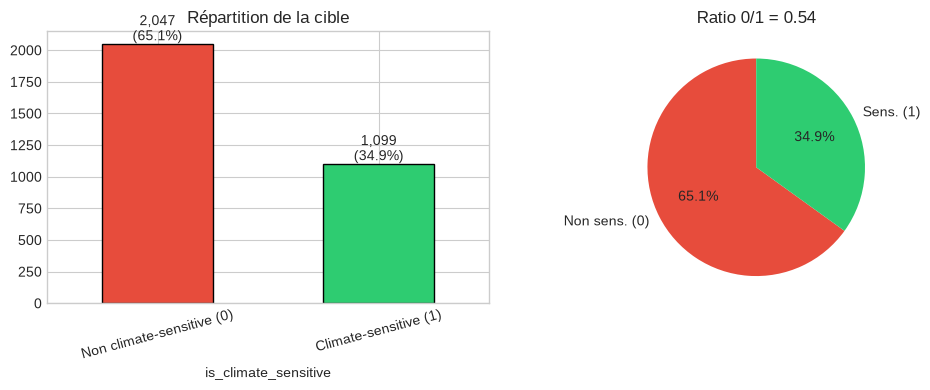

Classe 1 (climate-sensitive) : 65.1%
Classe 0                     : 34.9%


In [4]:
target_counts = train['is_climate_sensitive'].value_counts()
ratio = target_counts[0] / target_counts[1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
target_counts.plot.bar(ax=ax1, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax1.set_xticklabels(['Non climate-sensitive (0)', 'Climate-sensitive (1)'], rotation=15)
ax1.set_title('Répartition de la cible')
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():,}\n({p.get_height()/len(train):.1%})',
                 (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')

ax2.pie(target_counts, labels=['Non sens. (0)', 'Sens. (1)'],
        colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=90)
ax2.set_title(f'Ratio 0/1 = {ratio:.2f}')
plt.tight_layout()
plt.savefig('../notes/fig_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Classe 1 (climate-sensitive) : {target_counts[1]/len(train):.1%}')
print(f'Classe 0                     : {target_counts[0]/len(train):.1%}')

## 4. Signal dominant : l'âge

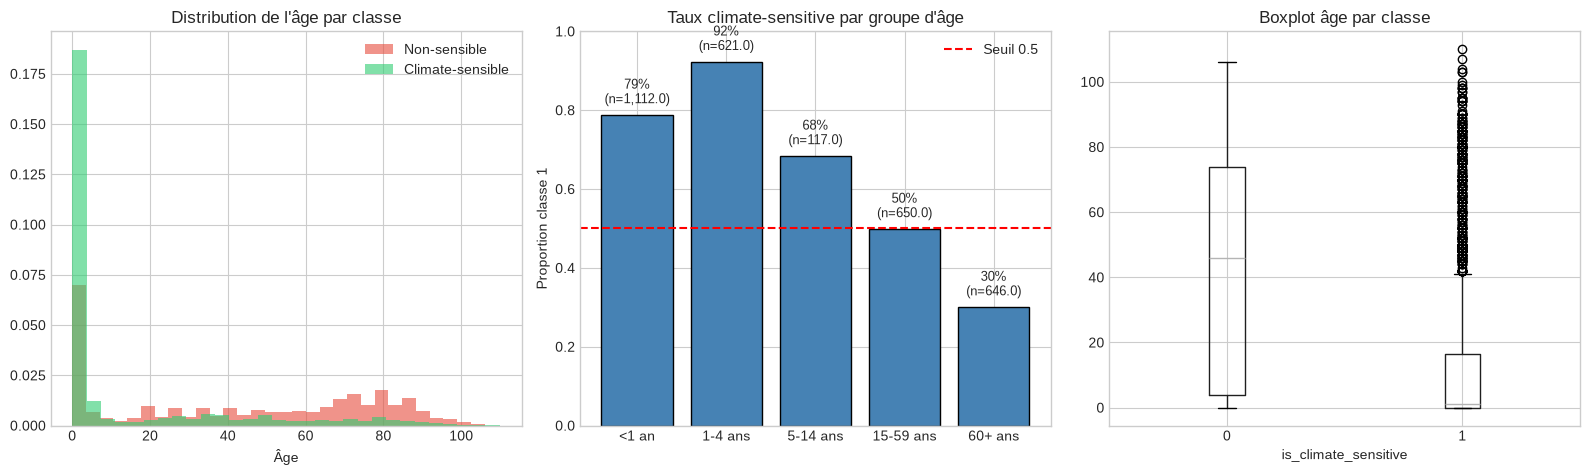

Corrélation âge / cible : -0.4433

            mean  count
age_group              
<1 an     0.7880   1112
1-4 ans   0.9230    621
5-14 ans  0.6840    117
15-59 ans 0.4980    650
60+ ans   0.3000    646


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution de l'âge par classe
for cls, color, label in [(0, '#e74c3c', 'Non-sensible'), (1, '#2ecc71', 'Climate-sensible')]:
    subset = train[train.is_climate_sensitive == cls]['age']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('Âge')
axes[0].set_title('Distribution de l\'âge par classe')
axes[0].legend()

# Taux cible par groupe d'âge
bins   = [0, 1, 5, 15, 60, 120]
labels = ['<1 an', '1-4 ans', '5-14 ans', '15-59 ans', '60+ ans']
train['age_group'] = pd.cut(train['age'], bins=bins, labels=labels, right=False)
ag_stats = train.groupby('age_group', observed=True)['is_climate_sensitive'].agg(['mean', 'count'])

bars = axes[1].bar(ag_stats.index, ag_stats['mean'], color='steelblue', edgecolor='black')
axes[1].axhline(0.5, color='red', linestyle='--', label='Seuil 0.5')
axes[1].set_ylim(0, 1)
axes[1].set_title('Taux climate-sensitive par groupe d\'âge')
axes[1].set_ylabel('Proportion classe 1')
for bar, (_, row) in zip(bars, ag_stats.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{row["mean"]:.0%}\n(n={row["count"]:,})', ha='center', va='bottom', fontsize=9)
axes[1].legend()

# Boxplot âge par classe
train.boxplot(column='age', by='is_climate_sensitive', ax=axes[2])
axes[2].set_title('Boxplot âge par classe')
axes[2].set_xlabel('is_climate_sensitive')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../notes/fig_age_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print('Corrélation âge / cible :', train['age'].corr(train['is_climate_sensitive']).round(4))
print()
print(ag_stats.round(3))

## 5. Structure temporelle — fuite ?

In [6]:
print('Train dates :', train.deathdate.min().date(), '->', train.deathdate.max().date())
print('Test  dates :', test.deathdate.min().date(),  '->', test.deathdate.max().date())

train_dates = set(train.deathdate.dt.date)
test_dates  = set(test.deathdate.dt.date)
print(f'\nDates en commun train/test : {len(train_dates & test_dates)}')
print('Années train :', sorted(train.deathdate.dt.year.unique()))
print('Années test  :', sorted(test.deathdate.dt.year.unique()))
print('\n→ Pas de fuite temporelle : train et test se chevauchent dans le temps.')
print('→ Split aléatoire justifié, pas de découpage chronologique nécessaire.')

Train dates : 2007-10-02 -> 2022-12-13
Test  dates : 2007-11-24 -> 2022-05-17

Dates en commun train/test : 466
Années train : [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]
Années test  : [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]

→ Pas de fuite temporelle : train et test se chevauchent dans le temps.
→ Split aléatoire justifié, pas de découpage chronologique nécessaire.


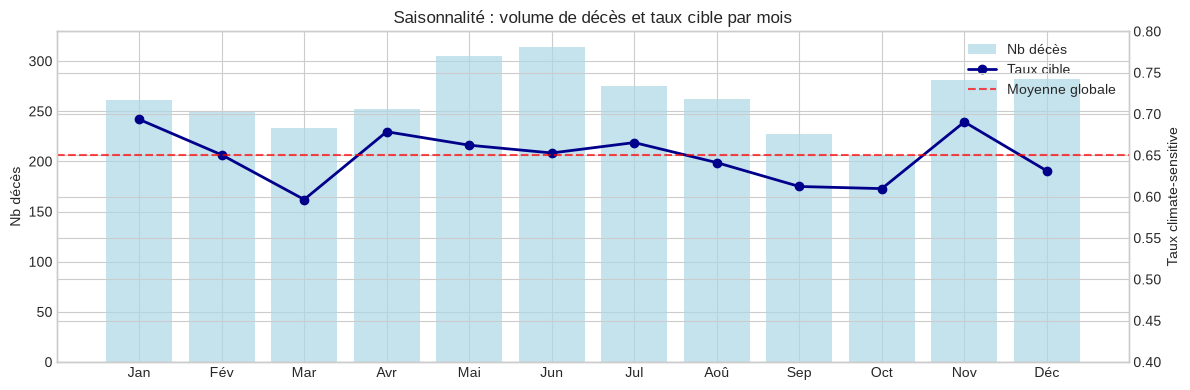

        mean  count
month              
1     0.6930    261
2     0.6510    249
3     0.5970    233
4     0.6790    252
5     0.6620    305
6     0.6530    314
7     0.6650    275
8     0.6410    262
9     0.6120    227
10    0.6100    205
11    0.6900    281
12    0.6310    282


In [7]:
# Saisonnalité du taux cible
train['month'] = train.deathdate.dt.month
monthly = train.groupby('month')['is_climate_sensitive'].agg(['mean', 'count'])

month_names = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.bar(range(1,13), monthly['count'], color='lightblue', label='Nb décès', alpha=0.7)
ax2.plot(range(1,13), monthly['mean'], color='darkblue', marker='o', linewidth=2, label='Taux cible')
ax2.axhline(train.is_climate_sensitive.mean(), color='red', linestyle='--', alpha=0.7, label='Moyenne globale')
ax2.set_ylim(0.4, 0.8)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(month_names)
ax1.set_ylabel('Nb décès')
ax2.set_ylabel('Taux climate-sensitive')
ax1.set_title('Saisonnalité : volume de décès et taux cible par mois')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig('../notes/fig_seasonality.png', dpi=120, bbox_inches='tight')
plt.show()
print(monthly.round(3))

## 6. Géographie — ALERTE fuite potentielle

In [8]:
train_locs = set(train.location.unique())
test_locs  = set(test.location.unique())
shared     = train_locs & test_locs

print(f'Locations train      : {len(train_locs)}')
print(f'Locations test       : {len(test_locs)}')
print(f'En commun            : {len(shared)}')
print(f'Only in test         : {test_locs - train_locs}')
print()
print('⚠️  Quasi-aucun overlap géographique train/test.')
print('→ EXCLURE "location" comme feature directe.')
print('→ Utiliser latitude, longitude, elevation comme proxies géographiques.')
print('→ GroupKFold par location pour la CV : simule la généralisation hors-zone.')

Locations train      : 39
Locations test       : 11
En commun            : 1
Only in test         : {'Bubago, Kamuli, Uganda', 'Lubaale, Lwemiyaga, Sembabule, Uganda', 'Nakalama, Iganga, Uganda', 'Kayanga, Mitooma, Western Region, Uganda', 'Matovu, Bugweri, Uganda', 'Nabitovu, Iganga, Uganda', 'Busowobi Central, Iganga, Uganda', 'Bukoteka, Bugweri, Uganda', 'Buseyi, Iganga, Uganda', 'Bunyama, Kagoonya, Bujumba, Kalangala, Uganda'}

⚠️  Quasi-aucun overlap géographique train/test.
→ EXCLURE "location" comme feature directe.
→ Utiliser latitude, longitude, elevation comme proxies géographiques.
→ GroupKFold par location pour la CV : simule la généralisation hors-zone.


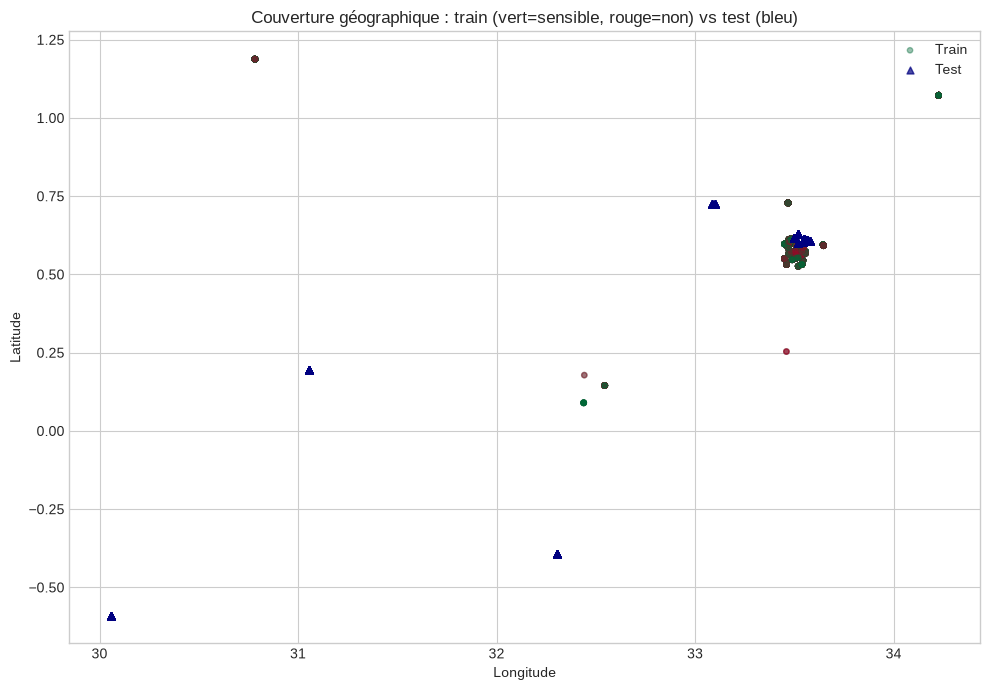

In [9]:
# Scatter géographique train vs test
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(train.longitude, train.latitude, c=train.is_climate_sensitive,
           cmap='RdYlGn', alpha=0.4, s=15, label='Train', marker='o')
ax.scatter(test.longitude, test.latitude, c='navy', alpha=0.7, s=25,
           label='Test', marker='^')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Couverture géographique : train (vert=sensible, rouge=non) vs test (bleu)')
ax.legend()
plt.tight_layout()
plt.savefig('../notes/fig_geography.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Features climatiques — corrélations avec la cible

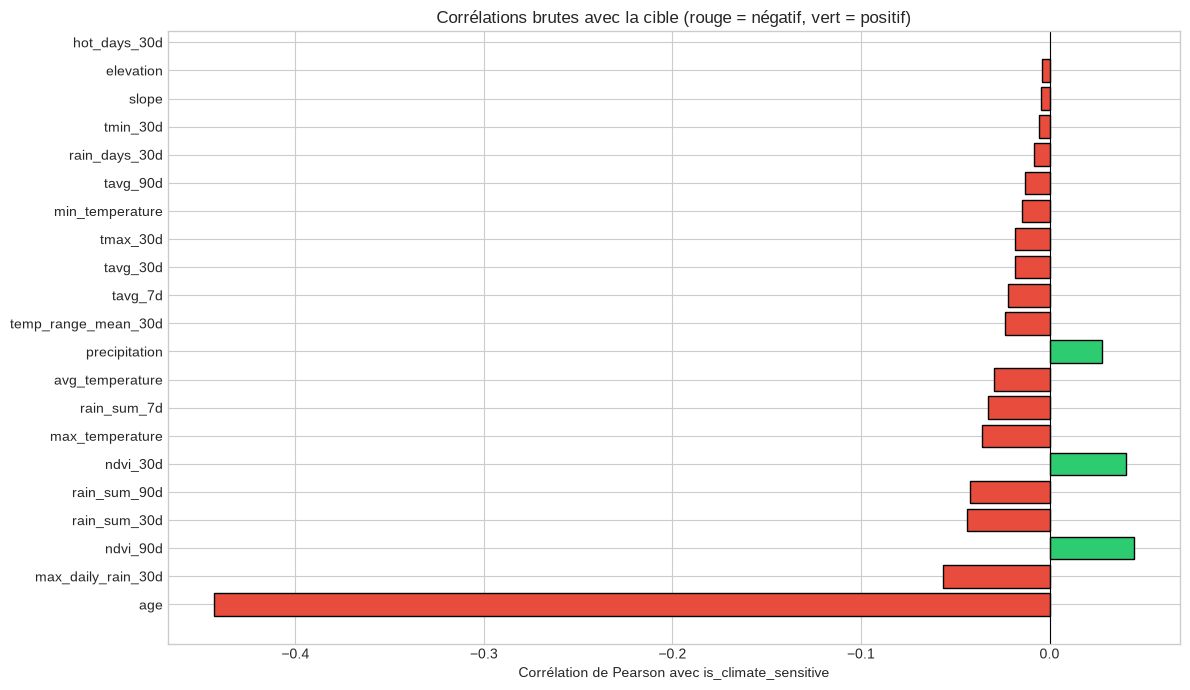

age                   -0.4433
max_daily_rain_30d    -0.0563
ndvi_90d               0.0448
rain_sum_30d          -0.0437
rain_sum_90d          -0.0420
ndvi_30d               0.0406
max_temperature       -0.0357
rain_sum_7d           -0.0328
avg_temperature       -0.0296
precipitation          0.0277
temp_range_mean_30d   -0.0235
tavg_7d               -0.0219
tavg_30d              -0.0184
tmax_30d              -0.0183
min_temperature       -0.0143
tavg_90d              -0.0130
rain_days_30d         -0.0080
tmin_30d              -0.0055
slope                 -0.0046
elevation             -0.0038
hot_days_30d              NaN
Name: is_climate_sensitive, dtype: float64


In [10]:
merged = train.merge(climate.drop(columns=['deathdate']), on='ID', how='left')

climate_cols = [
    'rain_sum_7d', 'rain_sum_30d', 'rain_sum_90d', 'rain_days_30d', 'max_daily_rain_30d',
    'tavg_7d', 'tavg_30d', 'tavg_90d', 'tmax_30d', 'tmin_30d', 'hot_days_30d',
    'temp_range_mean_30d', 'ndvi_30d', 'ndvi_90d', 'elevation', 'slope'
]
demo_cols = ['age', 'avg_temperature', 'max_temperature', 'min_temperature', 'precipitation']

all_num_cols = demo_cols + climate_cols
corr = merged[all_num_cols + ['is_climate_sensitive']].corr()['is_climate_sensitive'].drop('is_climate_sensitive')
corr_sorted = corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if corr[c] < 0 else '#2ecc71' for c in corr_sorted.index]
ax.barh(corr_sorted.index, corr[corr_sorted.index], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Corrélation de Pearson avec is_climate_sensitive')
ax.set_title('Corrélations brutes avec la cible (rouge = négatif, vert = positif)')
plt.tight_layout()
plt.savefig('../notes/fig_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

print(corr.sort_values(key=abs, ascending=False).round(4))

In [11]:
# hot_days_30d : variance ?
print('hot_days_30d value counts :')
print(merged['hot_days_30d'].value_counts())
print()
print('→ hot_days_30d = 0 pour 100% des observations. Feature morte à exclure.')

hot_days_30d value counts :
hot_days_30d
0    3146
Name: count, dtype: int64

→ hot_days_30d = 0 pour 100% des observations. Feature morte à exclure.


## 8. Interactions âge × climat

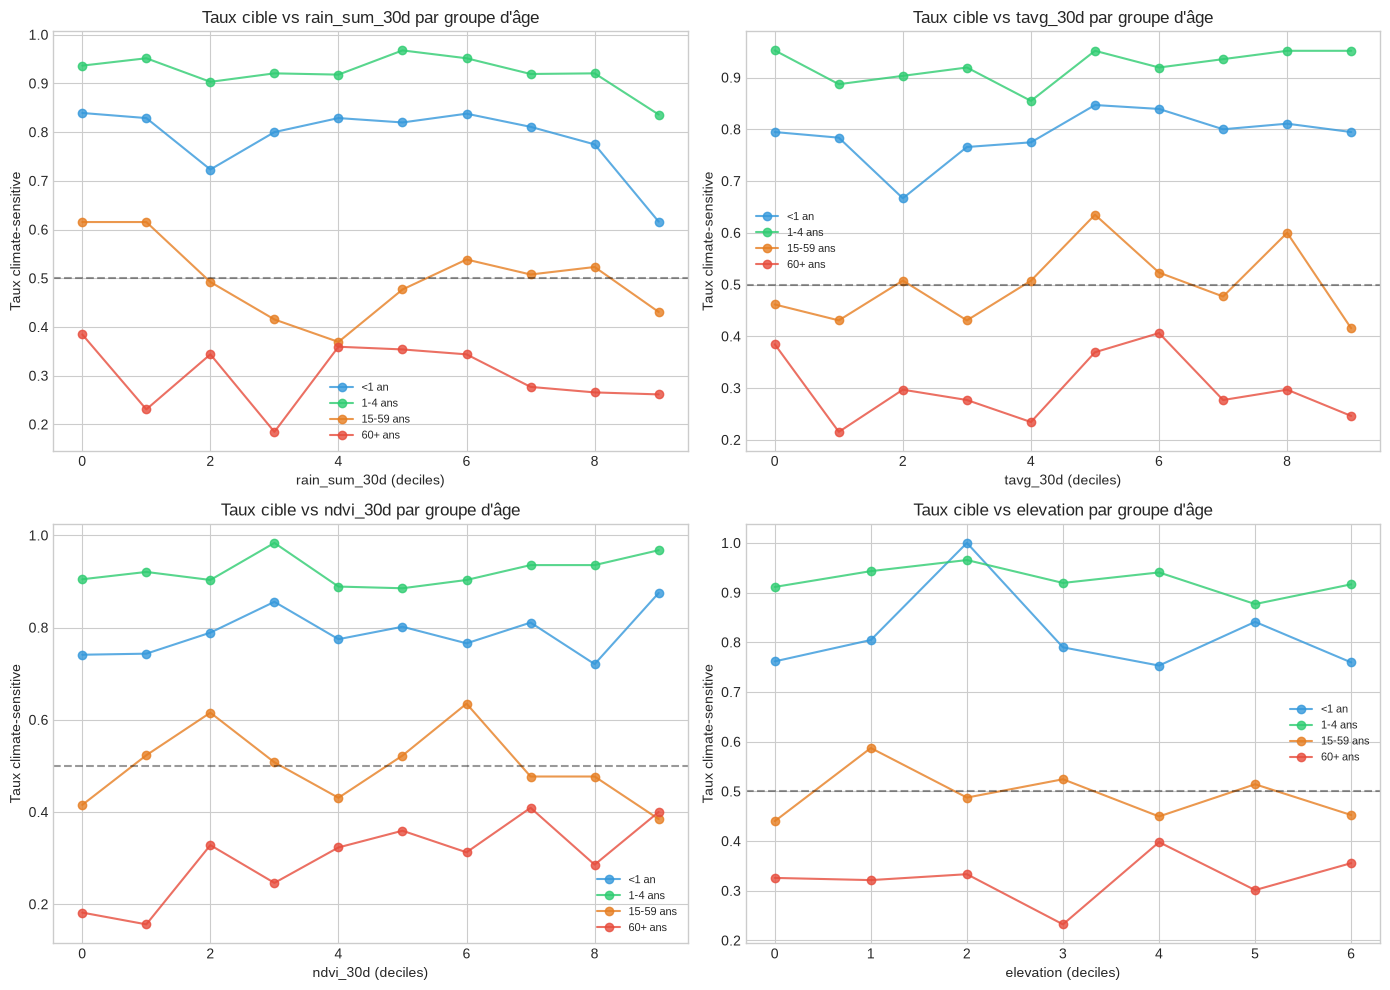

In [12]:
# Le signal clima pourrait être différent selon le groupe d'âge
key_climate = ['rain_sum_30d', 'tavg_30d', 'ndvi_30d', 'elevation']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, key_climate):
    for age_grp, color in [('<1 an','#3498db'), ('1-4 ans','#2ecc71'),
                            ('15-59 ans','#e67e22'), ('60+ ans','#e74c3c')]:
        subset = merged[merged['age_group'] == age_grp]
        if len(subset) < 10:
            continue
        # Taux cible par decile de la feature
        try:
            subset = subset.copy()
            subset['bin'] = pd.qcut(subset[col], q=10, duplicates='drop')
            rate = subset.groupby('bin', observed=True)['is_climate_sensitive'].mean()
            ax.plot(range(len(rate)), rate.values, marker='o', label=age_grp, color=color, alpha=0.8)
        except Exception:
            pass
    ax.set_title(f'Taux cible vs {col} par groupe d\'âge')
    ax.set_xlabel(f'{col} (deciles)')
    ax.set_ylabel('Taux climate-sensitive')
    ax.legend(fontsize=8)
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../notes/fig_age_climate_interactions.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Variables catégorielles

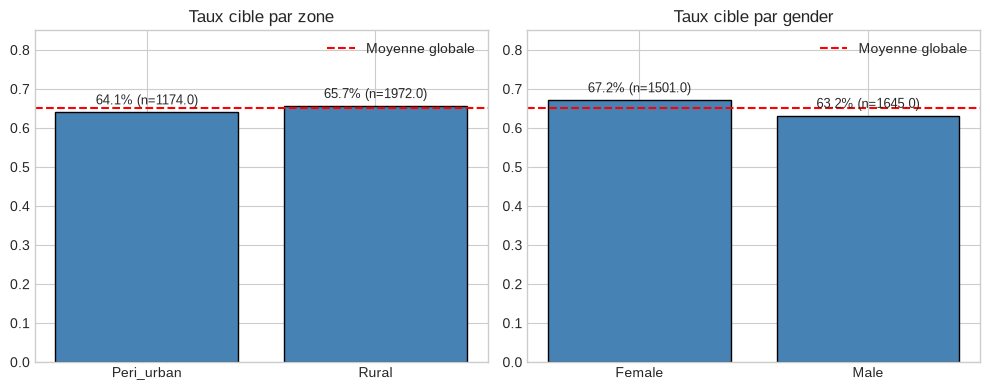

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ['zone', 'gender']):
    stats = train.groupby(col)['is_climate_sensitive'].agg(['mean', 'count'])
    bars = ax.bar(stats.index, stats['mean'], color='steelblue', edgecolor='black')
    ax.axhline(train.is_climate_sensitive.mean(), color='red', linestyle='--', label='Moyenne globale')
    ax.set_ylim(0, 0.85)
    ax.set_title(f'Taux cible par {col}')
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{row["mean"]:.1%} (n={row["count"]})', ha='center', fontsize=9)
    ax.legend()

plt.tight_layout()
plt.savefig('../notes/fig_categorical.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Matrice de corrélation des features numériques

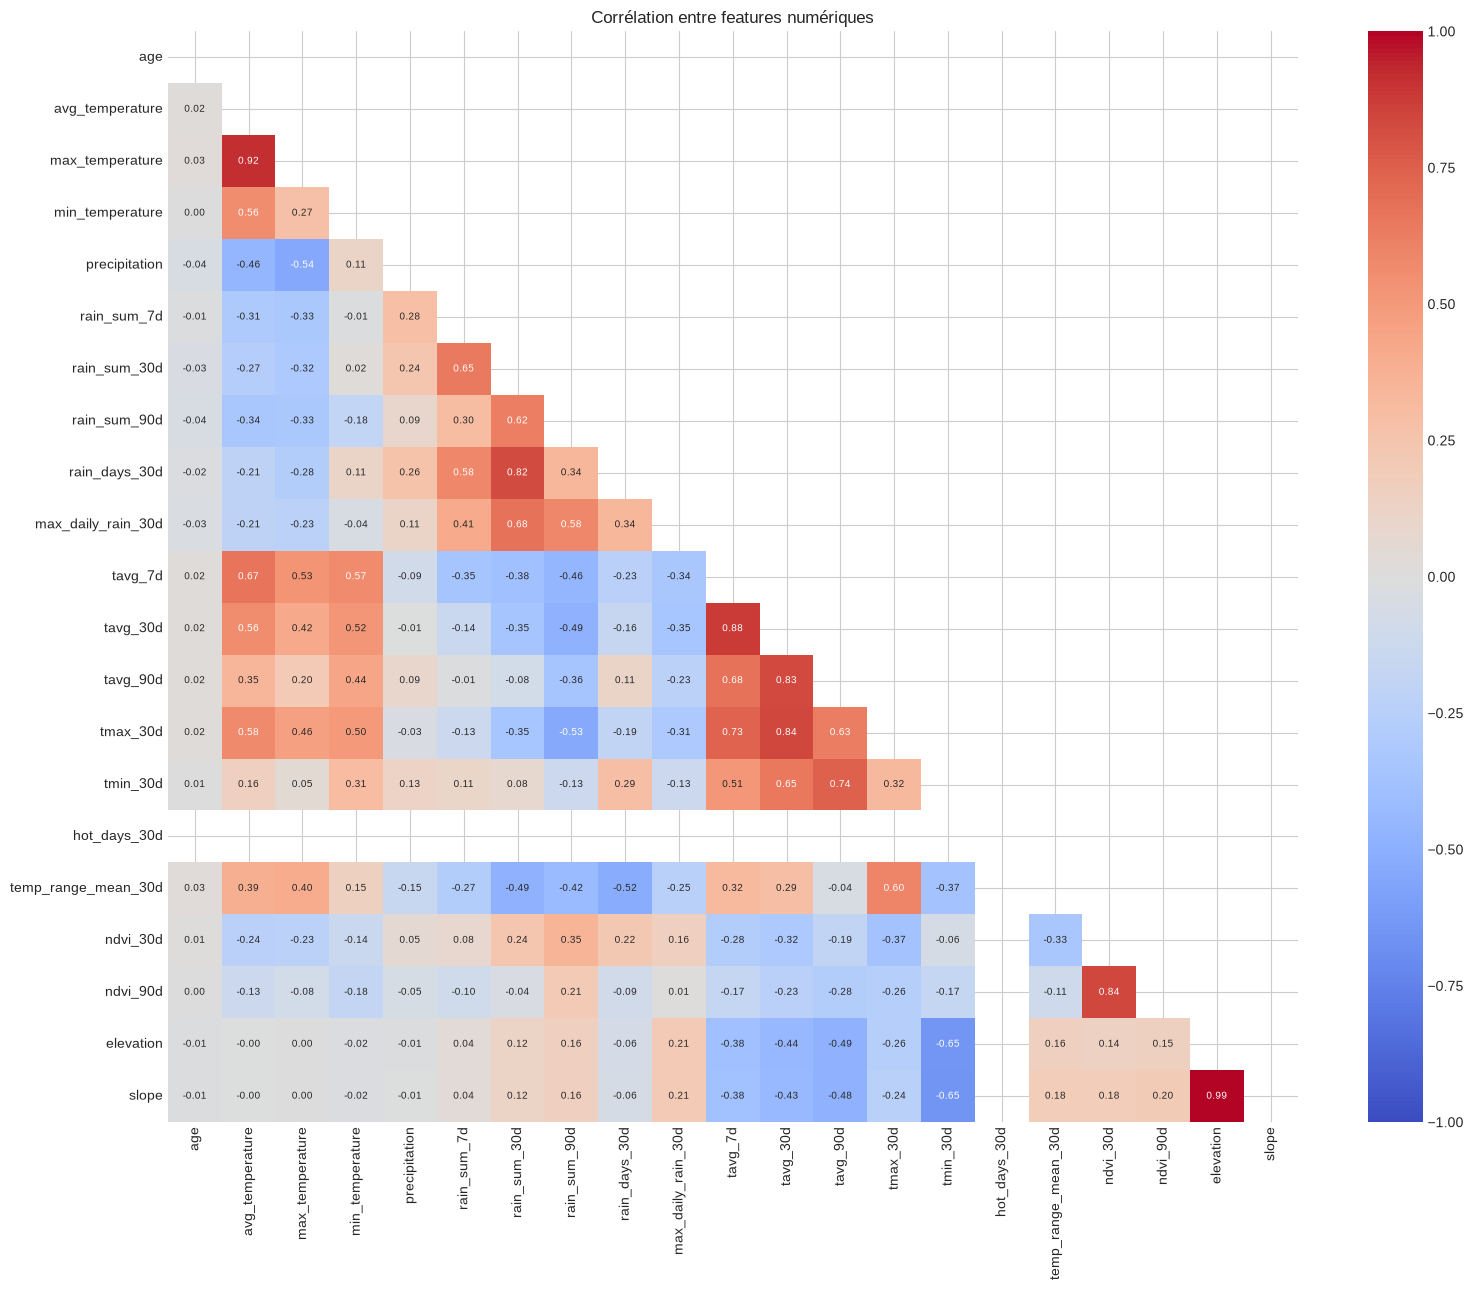

Features très corrélées (|r| > 0.9):
  elevation × slope : 0.993
  avg_temperature × max_temperature : 0.916


In [14]:
corr_matrix = merged[all_num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7})
ax.set_title('Corrélation entre features numériques')
plt.tight_layout()
plt.savefig('../notes/fig_corr_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('Features très corrélées (|r| > 0.9):')
high = [(c1,c2,corr_matrix.loc[c1,c2]) for i,c1 in enumerate(corr_matrix.columns)
        for c2 in corr_matrix.columns[i+1:]
        if abs(corr_matrix.loc[c1,c2]) > 0.9]
for c1,c2,r in sorted(high, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {c1} × {c2} : {r:.3f}')

## 11. Résumé des décisions EDA

In [15]:
print("""
=== DÉCISIONS ISSUES DE L'EDA ===

1. SIGNAL DOMINANT : âge (corr=-0.44)
   → Créer buckets d'âge + flags binaires (is_infant, is_child_u5, is_elderly)
   → Interactions âge × features climatiques

2. FEATURE MORTE : hot_days_30d (= 0 partout)
   → Exclure

3. FUITE GÉOGRAPHIQUE : location inutilisable (1 seul lieu commun train/test)
   → Exclure 'location'
   → Garder latitude, longitude, elevation comme proxies continus

4. SPLIT TEMPOREL : non nécessaire (train/test overlap temporel)
   → Utiliser GroupKFold par location pour la CV

5. DÉSÉQUILIBRE DE CLASSE : 65% / 35% (modéré)
   → class_weight='balanced' dans les modèles

6. FEATURES CLIMATIQUES : faible signal linéaire individuel
   → Valeur attendue dans les interactions et les non-linéarités (gradient boosting)

7. SAISONNALITÉ : présente mais faible (±5%)
   → Ajouter mois, saison_ouganda (deux saisons des pluies)

8. FEATURES TRÈS CORRÉLÉES à vérifier (potentielle redondance) :
   tavg_7d / tavg_30d / tavg_90d — rain_sum_7d / 30d / 90d
   → LightGBM gère nativement, mais envisager différences/anomalies
""")


=== DÉCISIONS ISSUES DE L'EDA ===

1. SIGNAL DOMINANT : âge (corr=-0.44)
   → Créer buckets d'âge + flags binaires (is_infant, is_child_u5, is_elderly)
   → Interactions âge × features climatiques

2. FEATURE MORTE : hot_days_30d (= 0 partout)
   → Exclure

3. FUITE GÉOGRAPHIQUE : location inutilisable (1 seul lieu commun train/test)
   → Exclure 'location'
   → Garder latitude, longitude, elevation comme proxies continus

4. SPLIT TEMPOREL : non nécessaire (train/test overlap temporel)
   → Utiliser GroupKFold par location pour la CV

5. DÉSÉQUILIBRE DE CLASSE : 65% / 35% (modéré)
   → class_weight='balanced' dans les modèles

6. FEATURES CLIMATIQUES : faible signal linéaire individuel
   → Valeur attendue dans les interactions et les non-linéarités (gradient boosting)

7. SAISONNALITÉ : présente mais faible (±5%)
   → Ajouter mois, saison_ouganda (deux saisons des pluies)

8. FEATURES TRÈS CORRÉLÉES à vérifier (potentielle redondance) :
   tavg_7d / tavg_30d / tavg_90d — rain_sum_7d